# Sentiment analiza i analiza emocija u dating aplikacijama

**NLP task:** Sentiment + emocije  
**Pristup:** Kombinacija klasifikacije sentimenta nad realnim korisničkim recenzijama i analize emocionalne progresije nad sintetičkim razgovorima.

Task se sastoji od dva povezana dijela:

1. **Sentiment analiza recenzija dating aplikacija**  
   Cilj je klasifikovati recenzije u tri klase: `negative`, `neutral` i `positive`.

2. **Analiza emocija u sintetičkim razgovorima**  
   Cilj je analizirati kako se emocije mijenjaju kroz različite tipove razgovora, npr. pad interesovanja, eskalacija frustracije, sarkazam i pozitivan tok razgovora.

Kod sentiment dijela testiraju se dva oblika tekstualne reprezentacije:

1. **TF-IDF** — klasična reprezentacija zasnovana na frekvenciji riječi i n-grama.
2. **Sentence-BERT** — kontekstualna reprezentacija teksta pomoću transformer modela.

Za emocije se zadržava TF-IDF klasifikator kao demonstracioni model, ali se rezultati ne interpretiraju kao dokaz stvarne generalizacije jer su razgovori sintetički i šablonizovani.


## 1. Import biblioteka i postavljanje putanja

Notebook je zamišljen da se pokreće iz foldera `notebooks`. Ako se pokrene iz root foldera projekta, putanje će se automatski prilagoditi.


In [50]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import GroupShuffleSplit

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

DATA = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"
REPORTS.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data:", DATA)
print("Reports folder:", REPORTS)


Project root: /Users/griza/Desktop/dap/dating-nlp
Processed data: /Users/griza/Desktop/dap/dating-nlp/data/processed
Reports folder: /Users/griza/Desktop/dap/dating-nlp/reports


## 2. Učitavanje podataka

Za ovaj task koriste se dvije grupe podataka:

- **Google Play recenzije dating aplikacija** — realne korisničke recenzije aplikacija kao što su Tinder, Bumble, Hinge i Coffee Meets Bagel. Sentiment labela je izvedena iz ocjene korisnika: niže ocjene su negativne, srednja ocjena je neutralna, a više ocjene su pozitivne.
- **Sintetički razgovori** — vještački generisani razgovori koji simuliraju različite emocionalne tokove u dating aplikacijama.

Važno je razlikovati ova dva izvora. Recenzije su realni korisnički podaci i pogodnije su za treniranje sentiment modela. Razgovori su sintetički i više su korisni za demonstraciju emocionalne progresije nego za ozbiljan emotion classifier.


In [51]:
reviews_train = pd.read_csv(DATA / "sentiment_reviews_train.csv")
reviews_val = pd.read_csv(DATA / "sentiment_reviews_val.csv")
reviews_test = pd.read_csv(DATA / "sentiment_reviews_test.csv")
reviews_all = pd.read_csv(DATA / "sentiment_reviews_clean.csv")

conversations = pd.read_csv(DATA / "sentiment_conversations_clean.csv")

print("Reviews train:", reviews_train.shape)
print("Reviews val:", reviews_val.shape)
print("Reviews test:", reviews_test.shape)
print("Reviews all:", reviews_all.shape)
print("Conversations:", conversations.shape)


Reviews train: (4341, 12)
Reviews val: (930, 12)
Reviews test: (931, 12)
Reviews all: (6202, 6)
Conversations: (2703, 7)


In [52]:
print("Kolone u reviews_train:")
print(reviews_train.columns.tolist())

print("\nKolone u conversations:")
print(conversations.columns.tolist())


Kolone u reviews_train:
['reviewId', 'userName', 'rating', 'text', 'review_date', 'app', 'app_id', 'sentiment', 'lang', 'text_clean', 'tokens_str', 'sentiment_label']

Kolone u conversations:
['conversation_id', 'turn_idx', 'flow', 'emotion', 'text', 'text_clean', 'tokens_str']


# 3. Sentiment analiza recenzija dating aplikacija

Sentiment analiza se radi nad recenzijama korisnika dating aplikacija. Klase su:

- `negative`
- `neutral`
- `positive`

Budući da korisnici češće ostavljaju recenzije kada su nezadovoljni, očekuje se nebalansirana raspodjela klasa. Zato se pored accuracy metrike koristi i **macro F1**, jer ona ravnopravnije tretira sve klase.


## 3.1 Distribucija sentiment klasa


In [53]:
reviews_all["sentiment_label"].value_counts()


sentiment_label
negative    4723
positive    1141
neutral      338
Name: count, dtype: int64

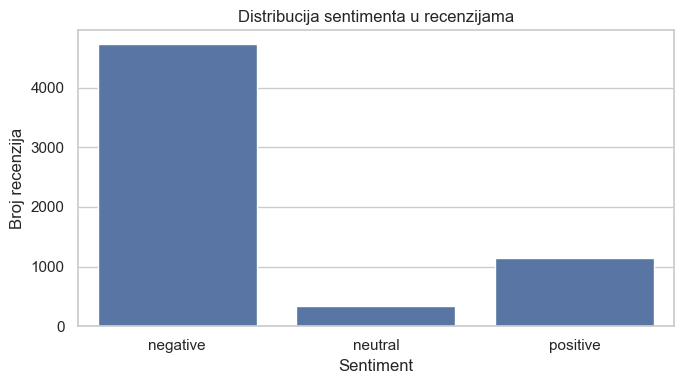

In [54]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=reviews_all,
    x="sentiment_label",
    order=["negative", "neutral", "positive"]
)
plt.title("Distribucija sentimenta u recenzijama")
plt.xlabel("Sentiment")
plt.ylabel("Broj recenzija")
plt.tight_layout()
plt.savefig(REPORTS / "sentiment_distribution.png", dpi=200)
plt.show()


Dataset je izrazito nebalansiran: negativne recenzije dominiraju, pozitivnih ima znatno manje, a neutralna klasa je najmanja. Zbog toga accuracy sama po sebi nije dovoljna metrika. Model koji uvijek predviđa `negative` već može ostvariti visoku accuracy, ali bi imao slab macro F1.


## 3.2 Distribucija ratinga

Pošto je sentiment labela izvedena iz korisničke ocjene, korisno je pogledati i raspodjelu ratinga.


In [55]:
reviews_all["rating"].value_counts().sort_index()


rating
1    4178
2     545
3     338
4     295
5     846
Name: count, dtype: int64

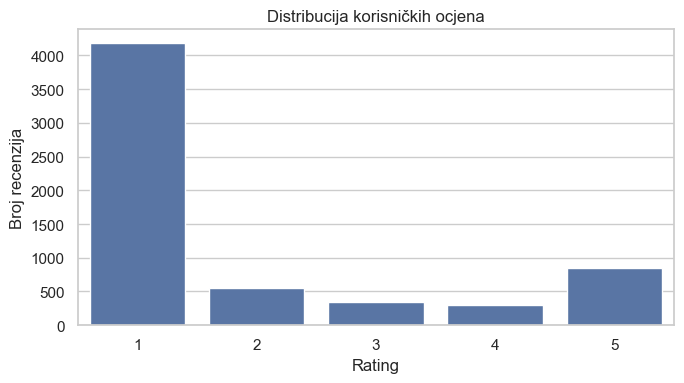

In [56]:
plt.figure(figsize=(7, 4))
sns.countplot(data=reviews_all, x="rating", order=sorted(reviews_all["rating"].dropna().unique()))
plt.title("Distribucija korisničkih ocjena")
plt.xlabel("Rating")
plt.ylabel("Broj recenzija")
plt.tight_layout()
plt.savefig(REPORTS / "sentiment_rating_distribution.png", dpi=200)
plt.show()


## 3.3 Sentiment po aplikaciji


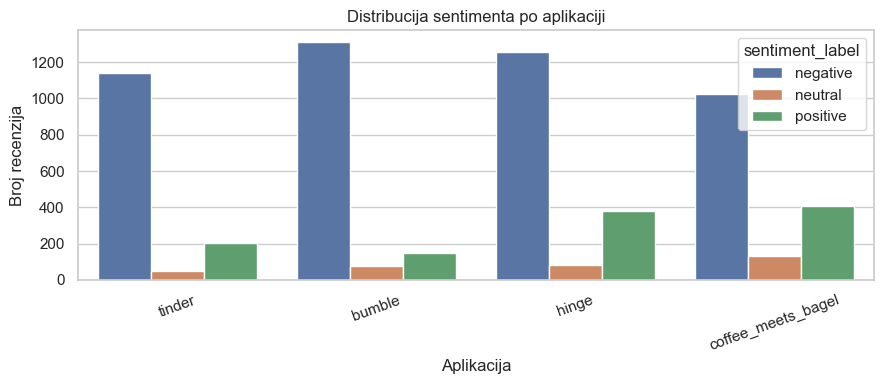

In [57]:
plt.figure(figsize=(9, 4))
sns.countplot(
    data=reviews_all,
    x="app",
    hue="sentiment_label",
    hue_order=["negative", "neutral", "positive"]
)
plt.title("Distribucija sentimenta po aplikaciji")
plt.xlabel("Aplikacija")
plt.ylabel("Broj recenzija")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(REPORTS / "sentiment_by_app.png", dpi=200)
plt.show()


## 3.4 Distribucija klasa u train/val/test skupovima

Pošto se model trenira na train skupu, podešava kroz validation skup i finalno testira na test skupu, potrebno je provjeriti da li je raspodjela klasa slična u sva tri skupa.


In [58]:
def split_distribution(df, split_name):
    counts = df["sentiment_label"].value_counts().rename("count")
    perc = (df["sentiment_label"].value_counts(normalize=True) * 100).rename("percent")
    out = pd.concat([counts, perc], axis=1)
    out["split"] = split_name
    return out.reset_index().rename(columns={"index": "sentiment_label"})

split_stats = pd.concat([
    split_distribution(reviews_train, "train"),
    split_distribution(reviews_val, "validation"),
    split_distribution(reviews_test, "test"),
], ignore_index=True)

split_stats


,sentiment_label,count,percent,split
0,negative,3306,76.157567,train
1,positive,799,18.405897,train
2,neutral,236,5.436535,train
3,negative,708,76.129032,validation
4,positive,171,18.387097,validation
5,neutral,51,5.483871,validation
6,negative,709,76.154672,test
7,positive,171,18.367347,test
8,neutral,51,5.477981,test


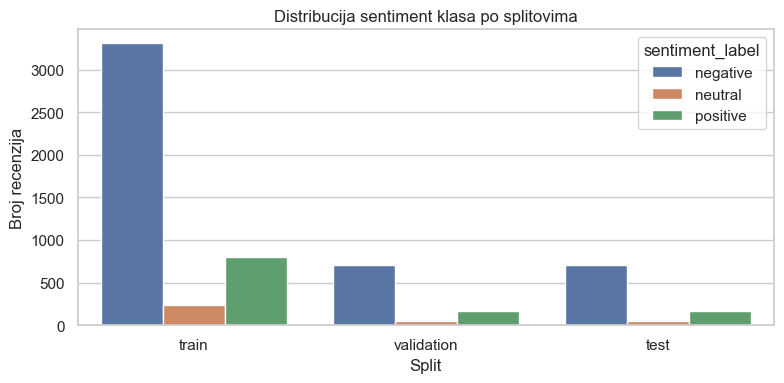

In [59]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=pd.concat([
        reviews_train.assign(split="train"),
        reviews_val.assign(split="validation"),
        reviews_test.assign(split="test"),
    ]),
    x="split",
    hue="sentiment_label",
    hue_order=["negative", "neutral", "positive"]
)
plt.title("Distribucija sentiment klasa po splitovima")
plt.xlabel("Split")
plt.ylabel("Broj recenzija")
plt.tight_layout()
plt.savefig(REPORTS / "sentiment_split_distribution.png", dpi=200)
plt.show()


## 3.5 Komentar za neutralnu klasu

Neutralna klasa je posebno problematična iz dva razloga:

1. Ima znatno manje primjera od negativne i pozitivne klase.
2. Nastala je iz ratinga 3, što ne mora uvijek značiti stvarno neutralan tekst. Korisnik može dati srednju ocjenu, ali u tekstu navesti i pozitivne i negativne komentare.

Zbog toga se očekuje da će model najteže prepoznavati upravo `neutral` klasu. U evaluaciji je zato važno gledati classification report po klasama, a ne samo ukupnu accuracy vrijednost.


# 4. Model 1: TF-IDF + LinearSVC za sentiment

Prvi model koristi TF-IDF reprezentaciju teksta i LinearSVC klasifikator. Ovaj pristup je sličan ostalim notebookima u projektu jer predstavlja klasični NLP baseline.

Za TF-IDF se koristi očišćeni tekst iz kolone `text_clean`.


In [60]:
def build_text_classifier(min_df=2, max_features=30000):
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=min_df,
            max_features=max_features,
            sublinear_tf=True
        )),
        ("clf", LinearSVC(
            class_weight="balanced",
            random_state=42,
            dual="auto"
        ))
    ])


In [61]:
X_train = reviews_train["text_clean"].fillna("")
y_train = reviews_train["sentiment_label"]

X_val = reviews_val["text_clean"].fillna("")
y_val = reviews_val["sentiment_label"]

X_test = reviews_test["text_clean"].fillna("")
y_test = reviews_test["sentiment_label"]

sentiment_model = build_text_classifier(min_df=2, max_features=30000)
sentiment_model.fit(X_train, y_train)

print("TF-IDF + LinearSVC sentiment model je istreniran.")


TF-IDF + LinearSVC sentiment model je istreniran.


In [62]:
def evaluate_model(model, X, y, labels, title, filename):
    pred = model.predict(X)

    acc = accuracy_score(y, pred)
    macro_f1 = f1_score(y, pred, average="macro")
    weighted_f1 = f1_score(y, pred, average="weighted")

    print(title)
    print("Accuracy:", round(acc, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    print()
    print(classification_report(y, pred, labels=labels, digits=3, zero_division=0))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y,
        pred,
        labels=labels,
        cmap="Blues",
        ax=ax
    )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(REPORTS / filename, dpi=200)
    plt.show()

    return {
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
    }


Sentiment model TF-IDF + LinearSVC - validacija
Accuracy: 0.8656
Macro F1: 0.6012
Weighted F1: 0.8492

              precision    recall  f1-score   support

    negative      0.895     0.953     0.923       708
     neutral      0.267     0.078     0.121        51
    positive      0.783     0.737     0.759       171

    accuracy                          0.866       930
   macro avg      0.648     0.590     0.601       930
weighted avg      0.840     0.866     0.849       930



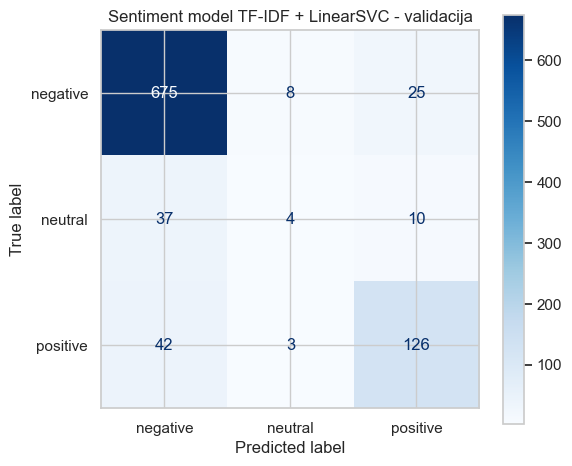

Sentiment model TF-IDF + LinearSVC - test
Accuracy: 0.87
Macro F1: 0.5897
Weighted F1: 0.8545

              precision    recall  f1-score   support

    negative      0.903     0.969     0.935       709
     neutral      0.136     0.059     0.082        51
    positive      0.811     0.702     0.752       171

    accuracy                          0.870       931
   macro avg      0.617     0.577     0.590       931
weighted avg      0.844     0.870     0.855       931



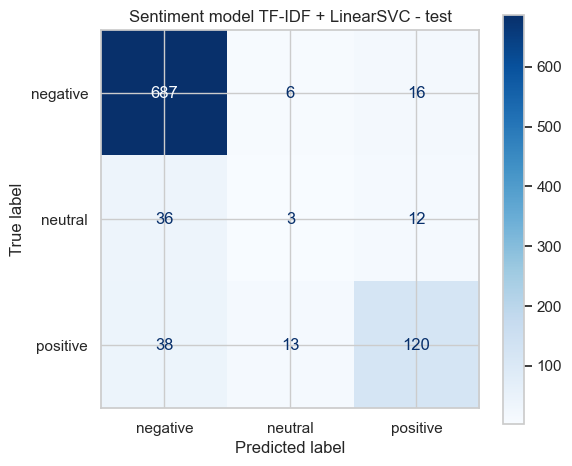

In [63]:
sentiment_labels = ["negative", "neutral", "positive"]

sentiment_val_metrics = evaluate_model(
    sentiment_model,
    X_val,
    y_val,
    sentiment_labels,
    "Sentiment model TF-IDF + LinearSVC - validacija",
    "sentiment_tfidf_confusion_val.png"
)

sentiment_test_metrics = evaluate_model(
    sentiment_model,
    X_test,
    y_test,
    sentiment_labels,
    "Sentiment model TF-IDF + LinearSVC - test",
    "sentiment_tfidf_confusion_test.png"
)

sentiment_test_pred_tfidf = sentiment_model.predict(X_test)


TF-IDF model se koristi kao osnovni, ali jak baseline. Kod ovakvih recenzija često dobro radi jer korisnički komentari sadrže prepoznatljive riječi koje upućuju na nezadovoljstvo ili zadovoljstvo aplikacijom. Ipak, zbog malog broja neutralnih primjera očekuje se slabiji rezultat za `neutral` klasu.


# 5. Dummy baseline

Dummy baseline uvijek predviđa najčešću klasu. Ovdje je to uglavnom `negative`. Ovaj baseline je važan jer pokazuje koliko accuracy može biti varljiva kod nebalansiranih podataka.


In [64]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print("Dummy accuracy:", round(accuracy_score(y_test, dummy_pred), 4))
print("Dummy macro F1:", round(f1_score(y_test, dummy_pred, average="macro"), 4))
print(classification_report(y_test, dummy_pred, labels=sentiment_labels, digits=3, zero_division=0))


Dummy accuracy: 0.7615
Dummy macro F1: 0.2882
              precision    recall  f1-score   support

    negative      0.762     1.000     0.865       709
     neutral      0.000     0.000     0.000        51
    positive      0.000     0.000     0.000       171

    accuracy                          0.762       931
   macro avg      0.254     0.333     0.288       931
weighted avg      0.580     0.762     0.658       931



# 6. Model 2: Sentence-BERT + Logistic Regression za sentiment

Drugi model koristi `Sentence-BERT` reprezentaciju teksta. Za razliku od TF-IDF-a, Sentence-BERT mapira cijelu recenziju u gusti vektor koji predstavlja semantičko značenje teksta.

Koristi se model `all-MiniLM-L6-v2`, isti stil pristupa kao u ostalim notebookima projekta. Za enkodiranje se koristi originalni tekst iz kolone `text`, jer BERT-ov tokenizator sam radi normalizaciju.

Napomena: prilikom prvog pokretanja model se preuzima sa Hugging Face-a, pa ova ćelija može trajati duže.


In [65]:
from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer("all-MiniLM-L6-v2")

print("Enkodiranje trening skupa...")
E_train = sbert.encode(reviews_train["text"].fillna("").tolist(), batch_size=64, show_progress_bar=True)
print("Enkodiranje validacijskog skupa...")
E_val = sbert.encode(reviews_val["text"].fillna("").tolist(), batch_size=64, show_progress_bar=True)
print("Enkodiranje testnog skupa...")
E_test = sbert.encode(reviews_test["text"].fillna("").tolist(), batch_size=64, show_progress_bar=True)

print(f"Dimenzija embedding vektora: {E_train.shape[1]}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Enkodiranje trening skupa...


Batches:   0%|          | 0/68 [00:00<?, ?it/s]

Enkodiranje validacijskog skupa...


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Enkodiranje testnog skupa...


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Dimenzija embedding vektora: 384


=== Sentence-BERT + Logistic Regression - validacijski skup ===
              precision    recall  f1-score   support

    negative      0.942     0.763     0.843       708
     neutral      0.130     0.451     0.202        51
    positive      0.711     0.749     0.729       171

    accuracy                          0.743       930
   macro avg      0.594     0.654     0.591       930
weighted avg      0.855     0.743     0.787       930



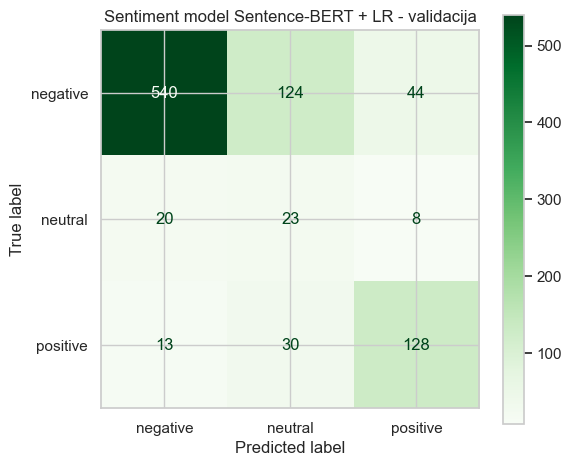

In [66]:
clf_sbert = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    C=1.0,
    random_state=42
)
clf_sbert.fit(E_train, y_train)

sentiment_val_pred_sbert = clf_sbert.predict(E_val)
sentiment_test_pred_sbert = clf_sbert.predict(E_test)

print("=== Sentence-BERT + Logistic Regression - validacijski skup ===")
print(classification_report(y_val, sentiment_val_pred_sbert, labels=sentiment_labels, digits=3, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    sentiment_val_pred_sbert,
    labels=sentiment_labels,
    cmap="Greens",
    ax=ax
)
plt.title("Sentiment model Sentence-BERT + LR - validacija")
plt.tight_layout()
plt.savefig(REPORTS / "sentiment_sbert_confusion_val.png", dpi=200)
plt.show()


=== Sentence-BERT + Logistic Regression - testni skup ===
              precision    recall  f1-score   support

    negative      0.951     0.767     0.849       709
     neutral      0.145     0.490     0.223        51
    positive      0.720     0.784     0.751       171

    accuracy                          0.755       931
   macro avg      0.605     0.680     0.608       931
weighted avg      0.865     0.755     0.797       931



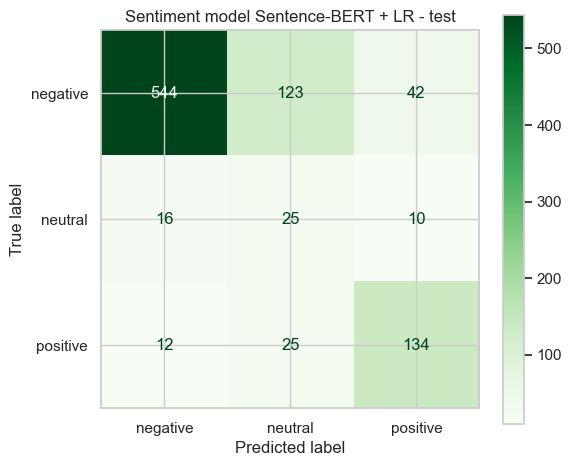

In [67]:
print("=== Sentence-BERT + Logistic Regression - testni skup ===")
print(classification_report(y_test, sentiment_test_pred_sbert, labels=sentiment_labels, digits=3, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    sentiment_test_pred_sbert,
    labels=sentiment_labels,
    cmap="Greens",
    ax=ax
)
plt.title("Sentiment model Sentence-BERT + LR - test")
plt.tight_layout()
plt.savefig(REPORTS / "sentiment_sbert_confusion_test.png", dpi=200)
plt.show()


# 7. Poređenje sentiment modela

U tabeli se porede tri pristupa:

- Dummy baseline
- TF-IDF + LinearSVC
- Sentence-BERT + Logistic Regression

Najvažnija metrika je **Macro F1**, jer dataset nije balansiran i neutralna klasa je mala.


In [68]:
def metric_row(y_true, y_pred, model_name, labels):
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0
    )
    row = {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Macro F1": round(f1_score(y_true, y_pred, average="macro"), 4),
        "Weighted F1": round(f1_score(y_true, y_pred, average="weighted"), 4),
    }
    for label in labels:
        row[f"F1 {label}"] = round(report[label]["f1-score"], 4)
    return row

sentiment_results = pd.DataFrame([
    metric_row(y_test, dummy_pred, "Dummy baseline", sentiment_labels),
    metric_row(y_test, sentiment_test_pred_tfidf, "TF-IDF + LinearSVC", sentiment_labels),
    metric_row(y_test, sentiment_test_pred_sbert, "Sentence-BERT + LR", sentiment_labels),
]).set_index("Model")

sentiment_results


,Accuracy,Macro F1,Weighted F1,F1 negative,F1 neutral,F1 positive
Model,,,,,,
Dummy baseline,0.7615,0.2882,0.6585,0.8646,0.0000,0.0000
TF-IDF + LinearSVC,0.8700,0.5897,0.8545,0.9347,0.0822,0.7524
Sentence-BERT + LR,0.7551,0.6078,0.7969,0.8493,0.2232,0.7507


Ova tabela omogućava fer poređenje modela. Ako Sentence-BERT ne nadmaši TF-IDF, to nije nužno problem. Kod recenzija aplikacija često postoje jako prepoznatljivi leksički signali, pa klasični TF-IDF može biti jednako dobar ili bolji od kontekstualnih embeddinga.


# 8. Analiza emocija u sintetičkim razgovorima

Drugi dio taska koristi sintetičke razgovore. Ovdje je važno naglasiti da dataset ne predstavlja stvarne korisničke razgovore, nego kontrolisane šablone emocionalnih tokova.

Zato se emotion classifier ne smije predstavljati kao jak model za realnu primjenu. On je koristan za demonstraciju pipeline-a i za analizu emocionalne progresije, ali ne dokazuje generalizaciju na stvarne razgovore.


## 8.1 Distribucija emocija


In [69]:
conversations["emotion"].value_counts()


emotion
interested    458
neutral       456
sarcastic     306
happy         288
bored         157
disengaged    157
playful       153
polite        146
annoyed       146
frustrated    146
angry         146
excited       144
Name: count, dtype: int64

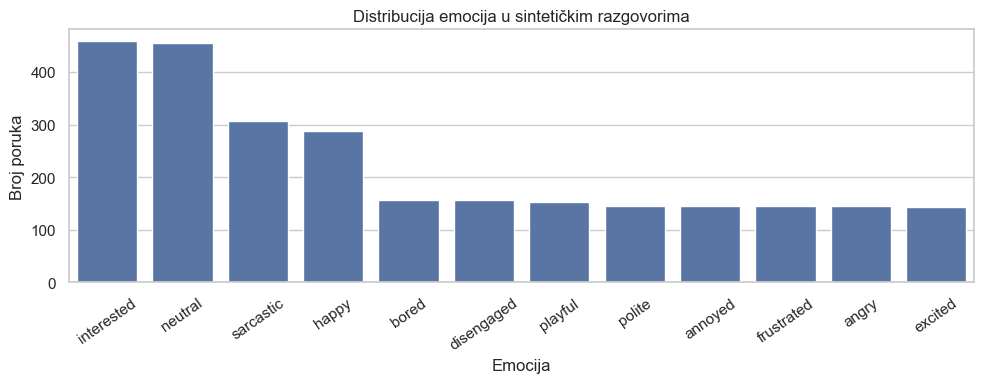

In [70]:
plt.figure(figsize=(10, 4))
sns.countplot(
    data=conversations,
    x="emotion",
    order=conversations["emotion"].value_counts().index
)
plt.title("Distribucija emocija u sintetičkim razgovorima")
plt.xlabel("Emocija")
plt.ylabel("Broj poruka")
plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig(REPORTS / "emotion_distribution.png", dpi=200)
plt.show()


## 8.2 Emocije po tipu razgovora


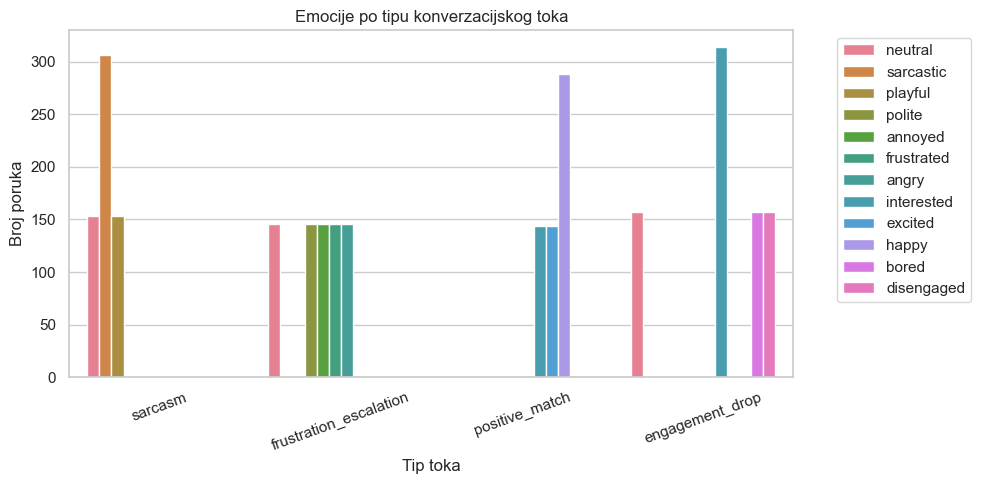

In [71]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=conversations,
    x="flow",
    hue="emotion"
)
plt.title("Emocije po tipu konverzacijskog toka")
plt.xlabel("Tip toka")
plt.ylabel("Broj poruka")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(REPORTS / "emotion_by_flow.png", dpi=200)
plt.show()


## 8.3 Provjera raznovrsnosti emotion dataseta

Prije treniranja emotion modela potrebno je provjeriti koliko dataset zaista sadrži različitih tekstova. Ako postoji mali broj jedinstvenih tekstova koji se ponavljaju kroz razgovore, model može ostvariti savršene rezultate zato što pamti šablone, a ne zato što razumije emocije.


In [72]:
print("Broj redova:", len(conversations))
print("Broj razgovora:", conversations["conversation_id"].nunique())
print("Broj jedinstvenih tekstova:", conversations["text_clean"].nunique())
print("Broj emocija:", conversations["emotion"].nunique())
print("Broj flow tipova:", conversations["flow"].nunique())


Broj redova: 2703
Broj razgovora: 600
Broj jedinstvenih tekstova: 37
Broj emocija: 12
Broj flow tipova: 4


In [73]:
unique_texts_by_emotion = (
    conversations
    .groupby("emotion")["text_clean"]
    .nunique()
    .sort_values()
    .rename("unique_text_count")
    .reset_index()
)

unique_texts_by_emotion


,emotion,unique_text_count
0,angry,1
1,annoyed,1
2,bored,1
3,disengaged,1
4,excited,1
5,frustrated,1
6,playful,1
7,polite,1
8,happy,2
9,sarcastic,2


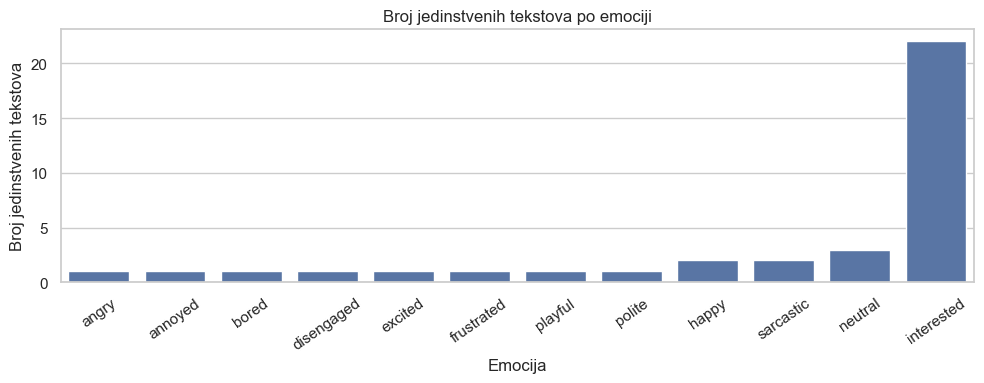

In [74]:
plt.figure(figsize=(10, 4))
sns.barplot(data=unique_texts_by_emotion, x="emotion", y="unique_text_count")
plt.title("Broj jedinstvenih tekstova po emociji")
plt.xlabel("Emocija")
plt.ylabel("Broj jedinstvenih tekstova")
plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig(REPORTS / "emotion_unique_texts_by_emotion.png", dpi=200)
plt.show()


Ako neke emocije imaju samo jedan ili vrlo malo jedinstvenih tekstualnih obrazaca, emotion model će vjerovatno učiti ponavljajuće fraze. Zato se savršeni rezultati ne smiju tumačiti kao stvarna sposobnost prepoznavanja emocija u realnim razgovorima.


## 8.4 Train/validation/test split po razgovorima

Za emotion dataset koristi se `GroupShuffleSplit`, gdje je `conversation_id` grupa. Time se sprječava da poruke iz istog razgovora budu i u train i u test skupu. Međutim, ovo ne rješava problem ako se isti tekstualni šabloni ponavljaju kroz različite razgovore.


In [75]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)

train_idx, temp_idx = next(
    gss.split(
        conversations,
        conversations["emotion"],
        groups=conversations["conversation_id"]
    )
)

conv_train = conversations.iloc[train_idx].reset_index(drop=True)
conv_temp = conversations.iloc[temp_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)

val_idx, test_idx = next(
    gss2.split(
        conv_temp,
        conv_temp["emotion"],
        groups=conv_temp["conversation_id"]
    )
)

conv_val = conv_temp.iloc[val_idx].reset_index(drop=True)
conv_test = conv_temp.iloc[test_idx].reset_index(drop=True)

print("Train/val/test shapes:", conv_train.shape, conv_val.shape, conv_test.shape)
print("Broj razgovora u train:", conv_train["conversation_id"].nunique())
print("Broj razgovora u validation:", conv_val["conversation_id"].nunique())
print("Broj razgovora u test:", conv_test["conversation_id"].nunique())


Train/val/test shapes: (1893, 7) (403, 7) (407, 7)
Broj razgovora u train: 420
Broj razgovora u validation: 90
Broj razgovora u test: 90


## 8.5 Provjera preklapanja tekstova između train i test skupa

Ovo je ključna provjera za sintetički dataset. Ako se isti tekstovi pojavljuju i u train i u test skupu, model može ostvariti jako visoke rezultate memorisanjem šablona.


In [76]:
train_texts = set(conv_train["text_clean"].fillna(""))
val_texts = set(conv_val["text_clean"].fillna(""))
test_texts = set(conv_test["text_clean"].fillna(""))

val_overlap = val_texts & train_texts
test_overlap = test_texts & train_texts

print(f"Validation unique tekstovi koji postoje u train skupu: {len(val_overlap)} / {len(val_texts)}")
print(f"Test unique tekstovi koji postoje u train skupu: {len(test_overlap)} / {len(test_texts)}")

pd.DataFrame({
    "split": ["validation", "test"],
    "unique_texts": [len(val_texts), len(test_texts)],
    "overlap_with_train": [len(val_overlap), len(test_overlap)],
    "overlap_percent": [
        round(100 * len(val_overlap) / max(len(val_texts), 1), 2),
        round(100 * len(test_overlap) / max(len(test_texts), 1), 2),
    ]
})


Validation unique tekstovi koji postoje u train skupu: 33 / 33
Test unique tekstovi koji postoje u train skupu: 31 / 31


,split,unique_texts,overlap_with_train,overlap_percent
0,validation,33,33,100.0
1,test,31,31,100.0


Ako je procenat preklapanja visok, rezultati emotion classifiera nisu pouzdan dokaz generalizacije. U tom slučaju emotion dio treba predstaviti kao demonstraciju nad kontrolisanim sintetičkim podacima, a ne kao model spreman za realnu primjenu.


# 9. Demonstracioni emotion classifier: TF-IDF + LinearSVC

U nastavku se trenira TF-IDF + LinearSVC model za emocije, ali se on interpretira oprezno. Cilj je pokazati da se šablonski tokovi mogu automatski klasifikovati, ne dokazati da model razumije emocije u stvarnim razgovorima.


In [77]:
X_emo_train = conv_train["text_clean"].fillna("")
y_emo_train = conv_train["emotion"]

X_emo_val = conv_val["text_clean"].fillna("")
y_emo_val = conv_val["emotion"]

X_emo_test = conv_test["text_clean"].fillna("")
y_emo_test = conv_test["emotion"]

emotion_model = build_text_classifier(min_df=1, max_features=10000)
emotion_model.fit(X_emo_train, y_emo_train)

print("Demonstracioni TF-IDF + LinearSVC emotion model je istreniran.")


Demonstracioni TF-IDF + LinearSVC emotion model je istreniran.


Emotion model TF-IDF + LinearSVC - validacija
Accuracy: 1.0
Macro F1: 1.0
Weighted F1: 1.0

              precision    recall  f1-score   support

       angry      1.000     1.000     1.000        16
     annoyed      1.000     1.000     1.000        16
       bored      1.000     1.000     1.000        27
  disengaged      1.000     1.000     1.000        27
     excited      1.000     1.000     1.000        16
  frustrated      1.000     1.000     1.000        16
       happy      1.000     1.000     1.000        32
  interested      1.000     1.000     1.000        70
     neutral      1.000     1.000     1.000        74
     playful      1.000     1.000     1.000        31
      polite      1.000     1.000     1.000        16
   sarcastic      1.000     1.000     1.000        62

    accuracy                          1.000       403
   macro avg      1.000     1.000     1.000       403
weighted avg      1.000     1.000     1.000       403



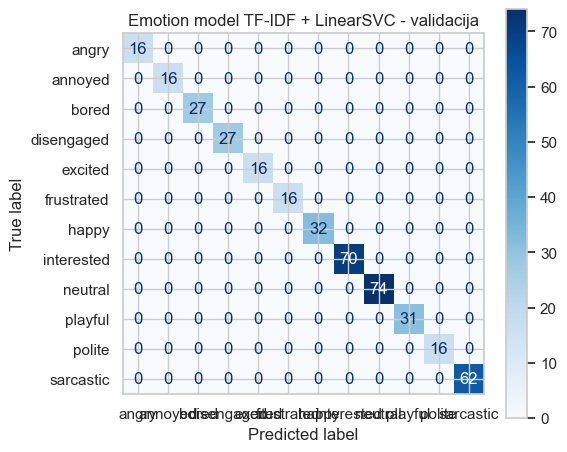

Emotion model TF-IDF + LinearSVC - test
Accuracy: 1.0
Macro F1: 1.0
Weighted F1: 1.0

              precision    recall  f1-score   support

       angry      1.000     1.000     1.000        22
     annoyed      1.000     1.000     1.000        22
       bored      1.000     1.000     1.000        25
  disengaged      1.000     1.000     1.000        25
     excited      1.000     1.000     1.000        20
  frustrated      1.000     1.000     1.000        22
       happy      1.000     1.000     1.000        40
  interested      1.000     1.000     1.000        70
     neutral      1.000     1.000     1.000        70
     playful      1.000     1.000     1.000        23
      polite      1.000     1.000     1.000        22
   sarcastic      1.000     1.000     1.000        46

    accuracy                          1.000       407
   macro avg      1.000     1.000     1.000       407
weighted avg      1.000     1.000     1.000       407



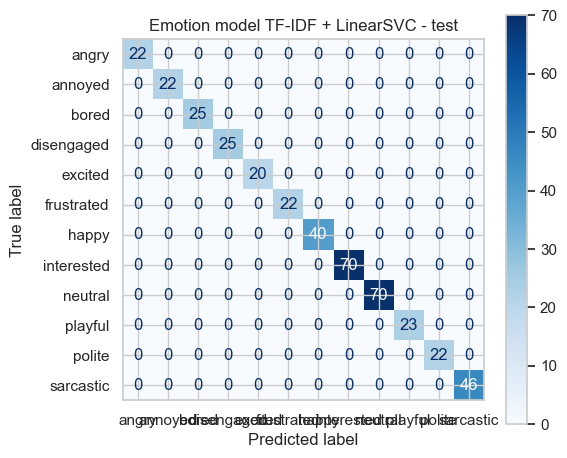

In [78]:
emotion_labels = sorted(conversations["emotion"].unique())

emotion_val_metrics = evaluate_model(
    emotion_model,
    X_emo_val,
    y_emo_val,
    emotion_labels,
    "Emotion model TF-IDF + LinearSVC - validacija",
    "emotion_confusion_val.png"
)

emotion_test_metrics = evaluate_model(
    emotion_model,
    X_emo_test,
    y_emo_test,
    emotion_labels,
    "Emotion model TF-IDF + LinearSVC - test",
    "emotion_confusion_test.png"
)


Visoki rezultati emotion modela ne znače nužno da je problem prepoznavanja emocija riješen. Pošto je dataset sintetički i sadrži mali broj ponavljajućih tekstualnih obrazaca, model vjerovatno uči šablone koji su korišteni pri generisanju podataka. Za stvarnu primjenu bilo bi potrebno koristiti raznovrsnije i po mogućnosti ručno anotirane razgovore.


# 10. Emocionalna progresija kroz razgovor

Ovaj dio je najkorisniji dio emotion analize. Umjesto da se fokus stavi samo na klasifikator, analizira se kako se prosječni emocionalni skor mijenja kroz različite tipove razgovora.

`emotion_score` je ručno definisana mapa emocija u numeričke vrijednosti. Ona služi samo za vizualizaciju toka razgovora i ne predstavlja psihološki validiranu mjeru emocije.


In [79]:
emotion_score = {
    "angry": -3.0,
    "frustrated": -2.5,
    "annoyed": -2.0,
    "disengaged": -1.5,
    "bored": -1.0,
    "sarcastic": -0.5,
    "neutral": 0.0,
    "polite": 0.5,
    "playful": 1.0,
    "interested": 1.5,
    "happy": 2.0,
    "excited": 2.5,
}

conversations["emotion_score"] = conversations["emotion"].map(emotion_score)


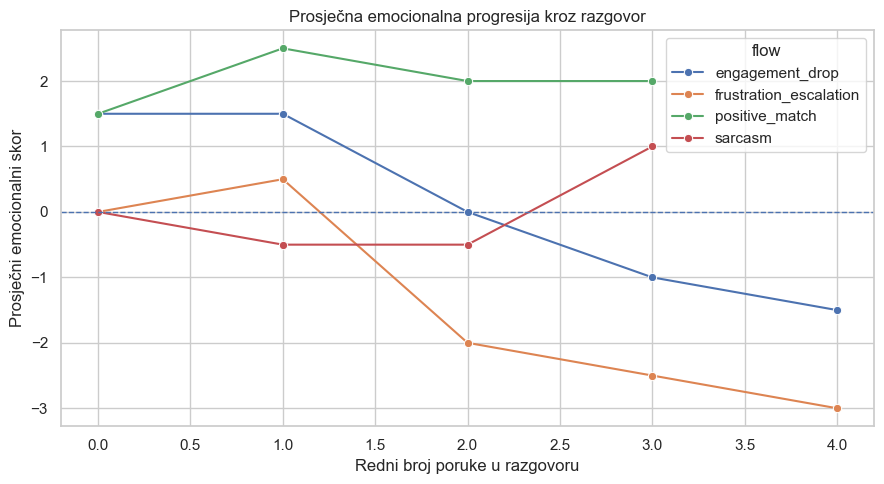

In [80]:
trajectory = (
    conversations
    .groupby(["flow", "turn_idx"], as_index=False)["emotion_score"]
    .mean()
)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=trajectory,
    x="turn_idx",
    y="emotion_score",
    hue="flow",
    marker="o"
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Prosječna emocionalna progresija kroz razgovor")
plt.xlabel("Redni broj poruke u razgovoru")
plt.ylabel("Prosječni emocionalni skor")
plt.tight_layout()
plt.savefig(REPORTS / "emotion_progression_by_flow.png", dpi=200)
plt.show()


Interpretacija flow tipova:

- `engagement_drop` — interesovanje opada kroz razgovor.
- `frustration_escalation` — neutralno stanje prelazi u frustraciju i ljutnju.
- `sarcasm` — pojavljuje se sarkastičan ton nakon generičkog otvaranja.
- `positive_match` — emocija se kreće ka sreći i uzbuđenju.


# 11. Export metrika

Metrike se spremaju u `reports/sentiment_emotion_metrics.json` kako bi se mogle koristiti u izvještaju ili prezentaciji.


In [81]:
metrics = {
    "sentiment": {
        "tfidf_linear_svc": {
            "validation": sentiment_val_metrics,
            "test": sentiment_test_metrics,
        },
        "comparison_test": sentiment_results.reset_index().to_dict(orient="records"),
    },
    "emotion": {
        "tfidf_linear_svc_demo": {
            "validation": emotion_val_metrics,
            "test": emotion_test_metrics,
        },
        "dataset_quality": {
            "rows": int(len(conversations)),
            "conversations": int(conversations["conversation_id"].nunique()),
            "unique_texts": int(conversations["text_clean"].nunique()),
            "emotions": int(conversations["emotion"].nunique()),
            "flows": int(conversations["flow"].nunique()),
            "val_overlap_with_train": int(len(val_overlap)),
            "test_overlap_with_train": int(len(test_overlap)),
        }
    }
}

with open(REPORTS / "sentiment_emotion_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

metrics


{'sentiment': {'tfidf_linear_svc': {'validation': {'accuracy': 0.8655913978494624,
    'macro_f1': 0.6012136262165105,
    'weighted_f1': 0.8491816868913447},
   'test': {'accuracy': 0.8700322234156821,
    'macro_f1': 0.5897455851838739,
    'weighted_f1': 0.8545024464265801}},
  'comparison_test': [{'Model': 'Dummy baseline',
    'Accuracy': 0.7615,
    'Macro F1': 0.2882,
    'Weighted F1': 0.6585,
    'F1 negative': 0.8646,
    'F1 neutral': 0.0,
    'F1 positive': 0.0},
   {'Model': 'TF-IDF + LinearSVC',
    'Accuracy': 0.87,
    'Macro F1': 0.5897,
    'Weighted F1': 0.8545,
    'F1 negative': 0.9347,
    'F1 neutral': 0.0822,
    'F1 positive': 0.7524},
   {'Model': 'Sentence-BERT + LR',
    'Accuracy': 0.7551,
    'Macro F1': 0.6078,
    'Weighted F1': 0.7969,
    'F1 negative': 0.8493,
    'F1 neutral': 0.2232,
    'F1 positive': 0.7507}]},
 'emotion': {'tfidf_linear_svc_demo': {'validation': {'accuracy': 1.0,
    'macro_f1': 1.0,
    'weighted_f1': 1.0},
   'test': {'accuracy

# 12. Zaključak

U ovom tasku obrađena su dva povezana problema: sentiment analiza recenzija dating aplikacija i analiza emocija u sintetičkim razgovorima.

Sentiment dio je metodološki jači jer koristi realne Google Play recenzije korisnika. Model klasifikuje recenzije u tri klase: `negative`, `neutral` i `positive`. Zbog nebalansirane raspodjele klasa, posebno malog broja neutralnih recenzija, za evaluaciju su važnije metrike kao što su macro F1 i classification report po klasama nego sama accuracy vrijednost. Neutralna klasa ostaje najteža za prepoznavanje jer je malobrojna i jer rating 3 ne mora uvijek predstavljati stvarno neutralan tekst.

U sentiment dijelu upoređena su tri pristupa: dummy baseline, TF-IDF + LinearSVC i Sentence-BERT + Logistic Regression. Dummy baseline pokazuje koliko accuracy može biti varljiva kod nebalansiranog dataseta, dok TF-IDF i Sentence-BERT daju realniju sliku performansi modela.

Emotion dio je koristan za demonstraciju emocionalnih tokova u dating razgovorima, ali ga treba interpretirati oprezno. Razgovori su sintetički i sadrže ograničen broj ponavljajućih tekstualnih obrazaca. Zbog toga visoki rezultati emotion classifiera ne dokazuju da bi model dobro radio nad stvarnim korisničkim razgovorima. Najvredniji dio emotion analize je vizualizacija emocionalne progresije kroz različite flow tipove, jer ona jasno prikazuje pad interesovanja, eskalaciju frustracije, sarkazam i pozitivan razvoj razgovora.

Za ozbiljniju buduću verziju emotion modela bilo bi potrebno proširiti dataset većim brojem raznovrsnih ili parafraziranih poruka, smanjiti broj emocija na stabilnije grupe ili koristiti stvarni ručno anotirani emotion dataset.
